## setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./data/all/some-removed/augmented-traditional-brightness/data.csv")
df

,name,thoracic_width,cardiac_width,ctr,cardiomegaly,gender,brightness,original_brightness
0,jsrt-JPCLN001,389.0,184.0,0.473,0,NaN,196.857890,196.857890
1,jsrt-JPCLN001_aug_grid_distortion_0,384.0,182.0,0.474,0,NaN,198.353504,198.353504
2,jsrt-JPCLN002,362.0,222.0,0.613,1,NaN,160.167768,160.167768
3,jsrt-JPCLN002_aug_gaussian_blur_0,362.0,222.0,0.613,1,NaN,160.406177,160.406177
4,jsrt-JPCLN003,371.0,184.0,0.496,0,NaN,206.884094,206.884094
...,...,...,...,...,...,...,...,...
3034,shenzhen-M-1544_aug_grid_distortion_0-aug1,343.0,169.0,0.493,0,M,213.516476,172.558128
3035,shenzhen-M-1556-aug1,372.0,148.0,0.398,0,M,219.489714,171.154969
3036,shenzhen-M-1556_aug_clarity_0-aug1,372.0,148.0,0.398,0,M,204.082253,159.414668
3037,shenzhen-M-1565-aug1,388.0,150.0,0.387,0,M,211.393033,168.309802


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
thoracic_width,3039.0,371.736426,43.315657,247.000000,340.000000,369.000000,399.000000,503.000000
cardiac_width,3039.0,178.110892,36.119169,96.000000,150.000000,173.000000,205.000000,318.000000
ctr,3039.0,0.479197,0.080110,0.350000,0.412000,0.472000,0.528000,0.750000
cardiomegaly,3039.0,0.384008,0.486440,0.000000,0.000000,0.000000,1.000000,1.000000
brightness,3039.0,155.939597,33.318583,84.902126,131.237051,154.449440,181.963271,219.740987
original_brightness,3039.0,156.482730,25.316599,84.902126,137.586237,152.936273,174.474353,216.707414


## ctr distrobution

In [4]:
def plot_ctr_histogram(df, range_step, xlim=(0,1), show_normal_range=True):
    step = range_step
    ctr_min = df['ctr'].min()
    ctr_max = df['ctr'].max()
    
    start = 0.50 + step * np.floor((ctr_min - 0.50) / step)
    stop = 0.50 + step * np.ceil((ctr_max - 0.50) / step)
    bin_edges = np.arange(start, stop, step)
    
    xlim_ticks = np.arange(xlim[0], xlim[1] + 0.0001, step)
    xlim_ticks = xlim_ticks[xlim_ticks <= xlim[1]]
    
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    sns.histplot(df['ctr'].dropna(), bins=bin_edges, color='orange')

    if show_normal_range:
        plt.axvline(x=0.42, color='blue', linestyle='--', label='Normal Aralık')
        plt.axvline(x=0.50, color='blue', linestyle='--')

    plt.xlim(xlim)
    plt.xticks(xlim_ticks)
    plt.title('KTO Dağılımı')
    plt.xlabel('KTO')
    plt.ylabel('Sayı')
    if show_normal_range:
        plt.legend()
    plt.show()

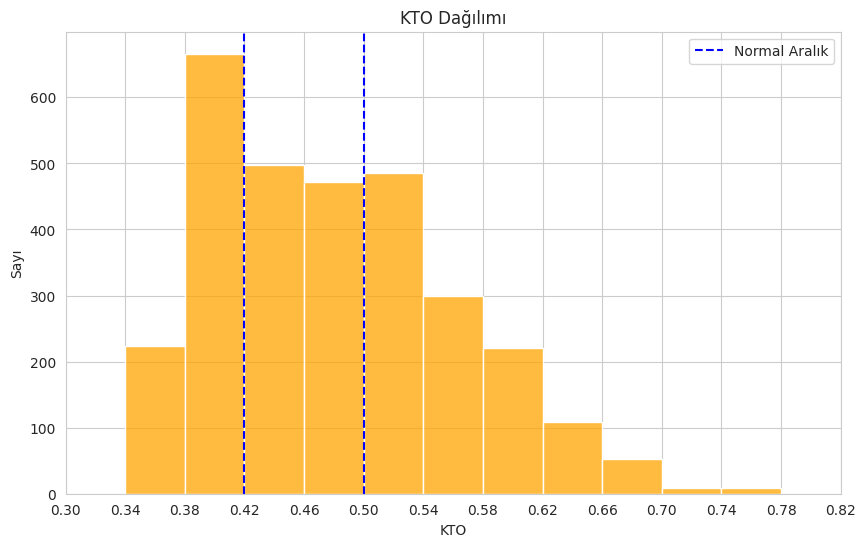

In [11]:
plot_ctr_histogram(df, 0.04, xlim=(0.30,0.82), show_normal_range=True)

## gender counts

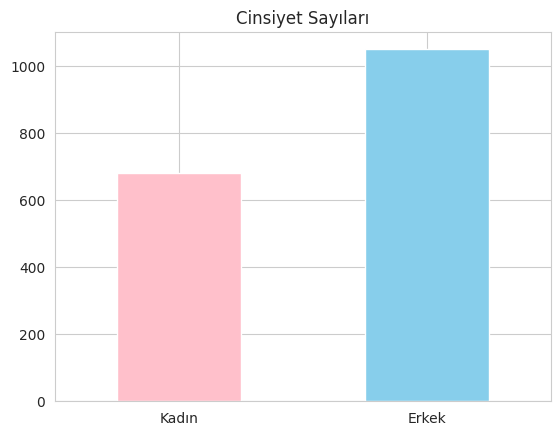

In [6]:
if 'gender' in df.columns and df['gender'].notna().any():
    gender_counts = df['gender'].value_counts(dropna=False).reindex(['F', 'M'], fill_value=0)
    gender_counts.plot(kind='bar', color=['pink', 'skyblue'])
    plt.title('Cinsiyet Sayıları')
    plt.xlabel('')
    plt.ylabel('')
    plt.xticks(ticks=[0, 1], labels=['Kadın', 'Erkek'], rotation=0)
    plt.show()

## brightness

In [7]:
def plot_brightness_histogram(df, range_step, xlim=(0, 255), ctr_only=False):
    step = range_step
    bin_edges = np.arange(0, 256 + step, step)
    
    if ctr_only:
        df = df.dropna(subset=['ctr'])
    brightness_values = df['brightness'].dropna()

    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    sns.histplot(brightness_values, bins=bin_edges, color='gray')
    plt.xticks(bin_edges)
    plt.xlim(xlim)
    plt.title('Parlaklık Dağılımı')
    plt.xlabel('Parlaklık')
    plt.ylabel('Sayı')
    plt.show()

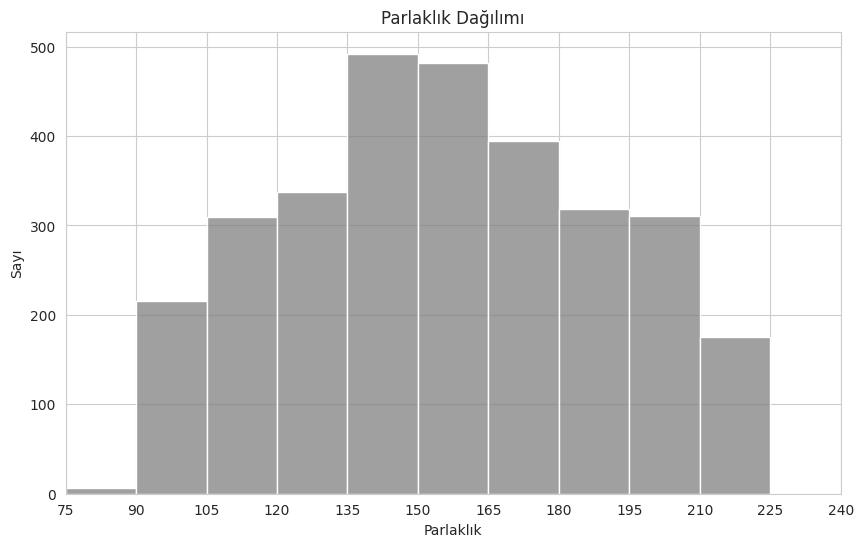

In [8]:
plot_brightness_histogram(df, 15, xlim=(75, 240), ctr_only=True)

## correlational analysis

In [9]:
def plot_brightness_ctr_correlation(df, xlim=(0, 255), ylim=(0,1), x_gap=15, y_gap=0.1):
    df_valid = df.dropna(subset=['ctr', 'brightness'])

    correlation = df_valid['brightness'].corr(df_valid['ctr'])
    print(f'Correlation coefficient: {correlation:.3f}')

    plt.figure(figsize=(8, 6))
    plt.scatter(df_valid['brightness'], df_valid['ctr'], alpha=0.5)
    plt.title('Parlaklık ve CTR Arasındaki Korelasyon')
    plt.xlabel('Parlaklık')
    plt.ylabel('CTR')

    plt.xlim(xlim)
    plt.ylim(ylim)

    def frange(start, stop, step):
        values = []
        while start <= stop:
            values.append(start)
            start = round(start + step, 10)
        return values

    plt.xticks(range(xlim[0], xlim[1] + 1, x_gap))
    y_ticks = [round(i, 2) for i in frange(ylim[0], ylim[1], y_gap)]
    plt.yticks(y_ticks)

    plt.grid(True)
    plt.tight_layout()
    plt.show()

Correlation coefficient: -0.204


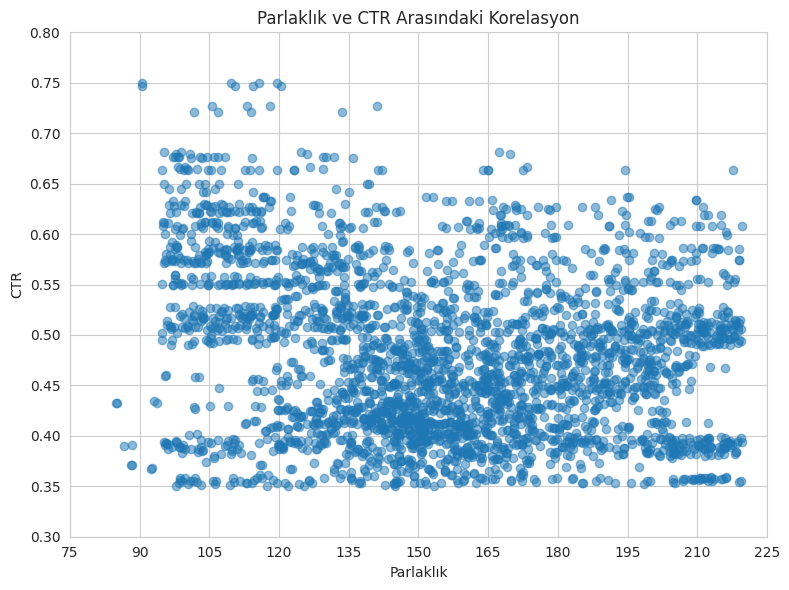

In [10]:
plot_brightness_ctr_correlation(df, xlim=(75, 225), ylim=(0.3,0.8), x_gap=15, y_gap=0.05)

## new